# SupportPilot AI — Data Understanding & Exploratory Data Analysis

## Tujuan

Notebook ini digunakan untuk memahami karakteristik dataset
Bitext Retail eCommerce sebelum dilakukan preprocessing dan
pemodelan.

Tahapan analisis meliputi:

- Memahami struktur dataset
- Memahami fungsi setiap kolom
- Memeriksa ukuran dataset
- Memeriksa tipe data
- Memeriksa missing values
- Memeriksa data duplikat
- Menganalisis distribusi kategori
- Menganalisis distribusi intent
- Menganalisis panjang teks
- Mengidentifikasi potensi masalah pada dataset

Dataset mentah tidak akan dimodifikasi pada tahap ini.

In [1]:
# import library
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# konfigurasi pandas 
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

In [3]:
# tentukan path dataset
DATA_PATH = Path("../data/raw/bitext_retail_ecommerce.csv")

print(DATA_PATH)

..\data\raw\bitext_retail_ecommerce.csv


In [4]:
# validasi file ada
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset tidak ditemukan: {DATA_PATH}"
    )

print("Dataset ditemukan.")

Dataset ditemukan.


In [5]:
# load dataset
df = pd.read_csv(DATA_PATH)

print("Dataset berhasil dimuat.")

Dataset berhasil dimuat.


In [6]:
df.head()

,instruction,intent,category,tags,response
0,I got to add an item to the cart,add_product,CART,BL,I'll get right on it! I'm here to assist you in adding an item to your cart. Here's a step-by-step guide to help you out:\n\n1. Browse through our...
1,wanna add fucking products to the basket can huelp me,add_product,CART,BCIMQWZ,I sincerely apologize if you've encountered any frustration with your previous experience. I'm here to assist you with adding products to your bas...
2,i have to add products to the basket i ned help,add_product,CART,BCMQZ,You bet! I'm here to assist you in adding products to your basket. Let me guide you through the process step by step:\n\n1. Start by browsing our ...
3,di like to add products to the cart could i get some help,add_product,CART,BCILMPQZ,Indeed! I'm here to assist you in adding products to your cart. Let me guide you through the process:\n\n1. Browse through our website and explore...
4,"I need to add an item to the cart , where do I do it?",add_product,CART,BCILZ,"I'll take care of it! I'm here to help you with adding items to your cart. To do that, simply follow these steps:\n\n1. Browse through our wide ra..."


## 1. Ukuran Dataset

Tahap pertama adalah mengetahui jumlah observasi dan fitur
yang terdapat dalam dataset.

In [7]:
rows, columns = df.shape

print(f"Jumlah baris : {rows:,}")
print(f"Jumlah kolom : {columns}")

Jumlah baris : 44,884
Jumlah kolom : 5


In [8]:
# nama kolom
print("Daftar kolom:")

for column in df.columns:
    print(f"- {column}")

Daftar kolom:
- instruction
- intent
- category
- tags
- response


### Penjelasan Kolom

| Kolom | Fungsi |
|---|---|
| `instruction` | Pertanyaan atau permintaan yang diberikan customer |
| `intent` | Label intent spesifik dari pertanyaan |
| `category` | Kelompok kategori tingkat tinggi dari intent |
| `tags` | Informasi mengenai variasi bahasa pada instruction |
| `response` | Contoh jawaban customer support |

Untuk proses Intent Classification:

**Feature (X):**

`instruction`

**Target (y):**

`intent`

Kolom `response` tidak digunakan sebagai target Intent Classification.

## 2. Struktur dan Tipe Data

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44884 entries, 0 to 44883
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   instruction  44884 non-null  str  
 1   intent       44884 non-null  str  
 2   category     44884 non-null  str  
 3   tags         44884 non-null  str  
 4   response     44884 non-null  str  
dtypes: str(5)
memory usage: 1.7 MB


In [10]:
# tipe data
df.dtypes

instruction    str
intent         str
category       str
tags           str
response       str
dtype: object

In [11]:
# liat sample acak
df.sample(
    n=5,
    random_state=42,
)

,instruction,intent,category,tags,response
33698,"I'd like information about the fucking sales, where can I get it?",sales_period,SALES,BCIPW,I genuinely apologize for the inappropriate language used in your instruction. I understand that you're interested in getting information about ou...
44212,one of the products in mh package is incorrect can i report it,wrong_item,DELIVERY,BCILQZ,"I'm sorry to hear that you received an incorrect product in your package. I understand how frustrating that must be. Don't worry, I'll assist you ..."
14749,im missing some fucking products i ordered how could i report them,missing_item,DELIVERY,BCILMPQW,"We regret the inconvenience, and we're sorry for any inconvenience caused by the missing item(s) in your order. I understand how frustrating that ..."
36515,im looking for information aboyt ur fucking shopping hours can ya help me,store_opening_hours,STORE,BCILMQWZ,I genuinely apologize for any frustration caused by your experience. I'm here to help you with the information you need about our store opening ho...
24333,I'd like information about the fucking status of my refund,refund_status,RETURNS,BPW,I sincerely apologize for the inconvenience and frustration you've experienced regarding the status of your refund. I understand how important it ...


## 3. Data Quality Check

### 3.1 Missing Values

Missing value perlu diperiksa karena nilai kosong pada feature
atau target dapat mengganggu proses preprocessing dan training model.

In [12]:
missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
)

missing_summary = pd.DataFrame(
    {
        "missing_count": missing_values,
        "missing_percentage": missing_percentage,
    }
)

missing_summary

,missing_count,missing_percentage
instruction,0,0.0
intent,0,0.0
category,0,0.0
tags,0,0.0
response,0,0.0


In [13]:
# check string kosong
empty_string_summary = {}

for column in df.columns:
    empty_count = (
        df[column]
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    empty_string_summary[column] = empty_count

pd.Series(
    empty_string_summary,
    name="empty_string_count",
)

instruction    0
intent         0
category       0
tags           0
response       0
Name: empty_string_count, dtype: int64

### 3.2 Duplicate Data

Data duplikat perlu diperiksa karena dapat menyebabkan model
melihat contoh yang sama berulang kali dan berpotensi
menghasilkan evaluasi yang terlalu optimistis.

In [14]:
duplicate_count = df.duplicated().sum()

duplicate_percentage = (
    duplicate_count / len(df)
) * 100

print(
    f"Jumlah duplicate row : {duplicate_count:,}"
)

print(
    f"Persentase duplicate : "
    f"{duplicate_percentage:.2f}%"
)

Jumlah duplicate row : 0
Persentase duplicate : 0.00%


In [15]:
# check duplicate instructions
duplicate_instruction = (
    df["instruction"]
    .duplicated()
    .sum()
)

print(
    f"Duplicate instruction: "
    f"{duplicate_instruction:,}"
)



Duplicate instruction: 0


In [16]:
normalized_instruction = (
    df["instruction"]
    .astype(str)
    .str.strip()
    .str.lower()
)

normalized_duplicate_count = (
    normalized_instruction
    .duplicated()
    .sum()
)

print(
    f"Duplicate instruction setelah "
    f"lowercase + strip: "
    f"{normalized_duplicate_count:,}"
)

Duplicate instruction setelah lowercase + strip: 57


In [33]:
# melihat bentuk duplicate nya
normalized_df = df.copy()

normalized_df["normalized_instruction"] = (
    normalized_df["instruction"]
    .astype(str)
    .str.strip()
    .str.lower()
)

normalized_duplicates = (
    normalized_df[
        normalized_df["normalized_instruction"]
        .duplicated(keep=False)
    ]
    .sort_values("normalized_instruction")
)

normalized_duplicates[
    [
        "instruction",
        "normalized_instruction",
        "intent",
        "category",
    ]
].head(20)

,instruction,normalized_instruction,intent,category
12638,help me exchange a product i purchased online in store,help me exchange a product i purchased online in store,exchange_product_in_store,PRODUCT
12539,help me exchange a product I purchased online in store,help me exchange a product i purchased online in store,exchange_product_in_store,PRODUCT
31988,help me returning a fucking product i bought online in store,help me returning a fucking product i bought online in store,return_product_in_store,RETURNS
31729,help me returning a fucking product I bought online in store,help me returning a fucking product i bought online in store,return_product_in_store,RETURNS
31832,help me returning a fucking product I purchased online in store,help me returning a fucking product i purchased online in store,return_product_in_store,RETURNS
31481,help me returning a fucking product i purchased online in store,help me returning a fucking product i purchased online in store,return_product_in_store,RETURNS
13405,help me to exchange a fucking item i bought online in store,help me to exchange a fucking item i bought online in store,exchange_product_in_store,PRODUCT
12530,help me to exchange a fucking item I bought online in store,help me to exchange a fucking item i bought online in store,exchange_product_in_store,PRODUCT
0,I got to add an item to the cart,i got to add an item to the cart,add_product,CART
450,i got to add an item to the cart,i got to add an item to the cart,add_product,CART


In [34]:
normalized_label_conflict = (
    normalized_duplicates
    .groupby("normalized_instruction")["intent"]
    .nunique()
)

conflicting_normalized_duplicates = (
    normalized_label_conflict[
        normalized_label_conflict > 1
    ]
)

print(
    "Normalized instruction dengan label intent berbeda:",
    len(conflicting_normalized_duplicates),
)

conflicting_normalized_duplicates

Normalized instruction dengan label intent berbeda: 0


Series([], Name: intent, dtype: int64)

## 4. Analisis Target dan Kategori

In [17]:
n_categories = df["category"].nunique()
n_intents = df["intent"].nunique()

print(f"Jumlah category : {n_categories}")
print(f"Jumlah intent   : {n_intents}")

Jumlah category : 13
Jumlah intent   : 46


In [18]:
# daftar category
categories = sorted(
    df["category"].dropna().unique()
)

for category in categories:
    print(category)

ACCOUNT
APP_WEBSITE
CART
CONTACT
DELIVERY
FEEDBACK
ORDER
PAYMENT
PRODUCT
RETURNS
SALES
STORE
USER


In [19]:
# daftar intent
intents = sorted(
    df["intent"].dropna().unique()
)

for index, intent in enumerate(
    intents,
    start=1,
):
    print(
        f"{index:02d}. {intent}"
    )

01. add_product
02. availability
03. availability_in_store
04. availability_online
05. cancel_order
06. change_account
07. change_order
08. close_account
09. customer_service
10. damaged_delivery
11. delivery_issue
12. delivery_time
13. exchange_product
14. exchange_product_in_store
15. human_agent
16. missing_item
17. open_account
18. order_history
19. pay
20. payment_issue
21. payment_methods
22. product_information
23. product_issue
24. recover_password
25. refund_policy
26. refund_status
27. remove_product
28. request_invoice
29. request_refund
30. request_right_to_rectification
31. return_policy
32. return_product
33. return_product_in_store
34. return_product_online
35. sales_period
36. shipping_costs
37. store_location
38. store_opening_hours
39. submit_feedback
40. submit_product_feedback
41. submit_product_idea
42. technical_issue
43. track_delivery
44. track_order
45. use_app
46. wrong_item


In [20]:
intent_category_check = (
    df.groupby("intent")["category"]
    .nunique()
    .sort_values(ascending=False)
)

intent_category_check

intent
add_product                       1
availability                      1
availability_in_store             1
availability_online               1
cancel_order                      1
change_account                    1
change_order                      1
close_account                     1
customer_service                  1
damaged_delivery                  1
delivery_issue                    1
delivery_time                     1
exchange_product                  1
exchange_product_in_store         1
human_agent                       1
missing_item                      1
open_account                      1
order_history                     1
pay                               1
payment_issue                     1
payment_methods                   1
product_information               1
product_issue                     1
recover_password                  1
refund_policy                     1
refund_status                     1
remove_product                    1
request_invoice      

In [21]:
inconsistent_intents = (
    intent_category_check[
        intent_category_check > 1
    ]
)

print(
    f"Intent dengan lebih dari satu category: "
    f"{len(inconsistent_intents)}"
)

inconsistent_intents

Intent dengan lebih dari satu category: 0


Series([], Name: category, dtype: int64)

In [22]:
# distribusi category
category_distribution = (
    df["category"]
    .value_counts()
)

category_distribution

category
RETURNS        6925
PRODUCT        6679
DELIVERY       6595
ACCOUNT        4950
ORDER          3945
PAYMENT        2981
FEEDBACK       2980
APP_WEBSITE    1993
CONTACT        1986
CART           1950
STORE          1916
SALES           995
USER            989
Name: count, dtype: int64

In [23]:
# persentase distribusi category
category_percentage = (
    df["category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

category_percentage

category
RETURNS        15.43
PRODUCT        14.88
DELIVERY       14.69
ACCOUNT        11.03
ORDER           8.79
PAYMENT         6.64
FEEDBACK        6.64
APP_WEBSITE     4.44
CONTACT         4.42
CART            4.34
STORE           4.27
SALES           2.22
USER            2.20
Name: proportion, dtype: float64

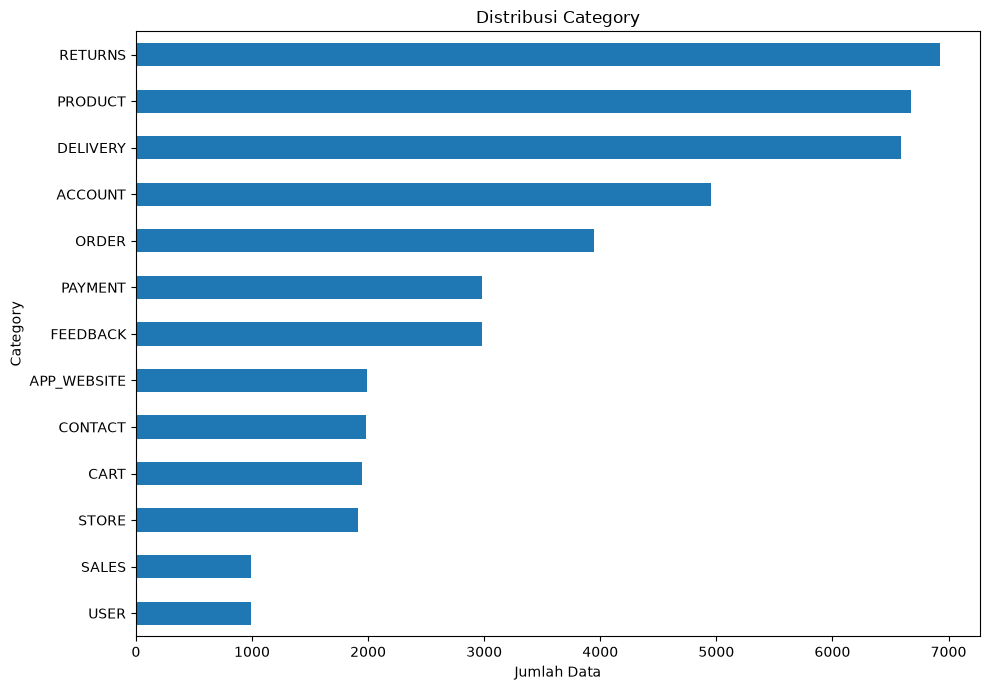

In [24]:
# viusalisasi distribusi category
category_distribution.sort_values().plot(
    kind="barh",
    figsize=(10, 7),
)

plt.title(
    "Distribusi Category"
)

plt.xlabel(
    "Jumlah Data"
)

plt.ylabel(
    "Category"
)

plt.tight_layout()

plt.show()

In [25]:
# distribusi intent
intent_distribution = (
    df["intent"]
    .value_counts()
)

intent_distribution

intent
request_invoice                   1000
refund_status                      999
use_app                            999
cancel_order                       996
delivery_issue                     996
payment_issue                      996
track_delivery                     996
wrong_item                         996
close_account                      995
payment_methods                    995
sales_period                       995
submit_product_idea                995
human_agent                        994
refund_policy                      994
return_policy                      994
return_product                     994
return_product_in_store            994
submit_product_feedback            994
technical_issue                    994
availability_online                993
recover_password                   993
remove_product                     993
return_product_online              993
customer_service                   992
damaged_delivery                   992
product_issue     

In [26]:
intent_distribution.describe()

count      46.00000
mean      975.73913
std        54.02980
min       721.00000
25%       987.25000
50%       992.50000
75%       994.75000
max      1000.00000
Name: count, dtype: float64

In [27]:
# top dan bottom intent
print("10 intent dengan data terbanyak:")

display(
    intent_distribution.head(10)
)

print("\n10 intent dengan data paling sedikit:")

display(
    intent_distribution.tail(10)
)

10 intent dengan data terbanyak:


intent
request_invoice    1000
refund_status       999
use_app             999
cancel_order        996
delivery_issue      996
payment_issue       996
track_delivery      996
wrong_item          996
close_account       995
payment_methods     995
Name: count, dtype: int64


10 intent dengan data paling sedikit:


intent
product_information      987
shipping_costs           974
availability             972
change_order             961
add_product              957
request_refund           957
store_location           924
delivery_time            920
availability_in_store    756
missing_item             721
Name: count, dtype: int64

## 5. Analisis Panjang Teks

Panjang instruction perlu dianalisis untuk memahami
karakteristik input yang nantinya akan diterima oleh model.

In [28]:
df_analysis = df.copy()

df_analysis["instruction_char_length"] = (
    df_analysis["instruction"]
    .astype(str)
    .str.len()
)

df_analysis["instruction_word_count"] = (
    df_analysis["instruction"]
    .astype(str)
    .str.split()
    .str.len()
)

In [29]:
# statistik panjang teks
df_analysis[
    [
        "instruction_char_length",
        "instruction_word_count",
    ]
].describe()

,instruction_char_length,instruction_word_count
count,44884.000000,44884.000000
mean,58.365899,11.801711
std,15.069755,2.910465
min,3.000000,1.000000
25%,48.000000,10.000000
50%,58.000000,12.000000
75%,68.000000,14.000000
max,131.000000,24.000000


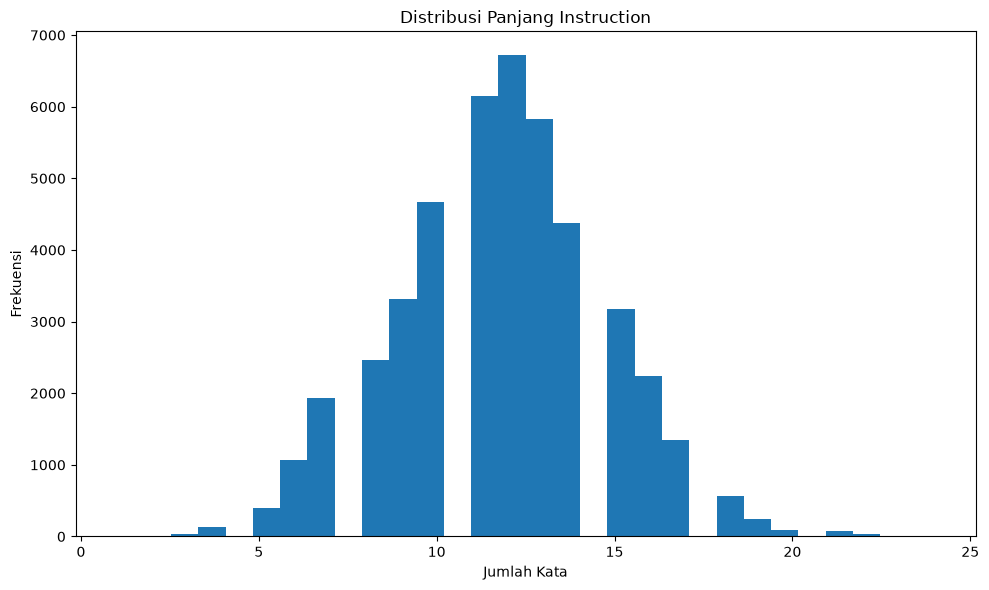

In [30]:
# histogram
df_analysis[
    "instruction_word_count"
].plot(
    kind="hist",
    bins=30,
    figsize=(10, 6),
)

plt.title(
    "Distribusi Panjang Instruction"
)

plt.xlabel(
    "Jumlah Kata"
)

plt.ylabel(
    "Frekuensi"
)

plt.tight_layout()

plt.show()

In [31]:
# pertanyaan terpendek dan terpanjang
shortest = (
    df_analysis
    .sort_values(
        "instruction_word_count"
    )
    [
        [
            "instruction",
            "intent",
            "instruction_word_count",
        ]
    ]
    .head(10)
)

shortest

,instruction,intent,instruction_word_count
17378,apy,pay,1
15217,wanna register,open_account,2
17661,make tyransfers,pay,2
15681,wanna register,open_account,2
17794,check oit,pay,2
14683,reportmissing items,missing_item,2
42803,trackmy order,track_order,2
12069,exchange some items,exchange_product,3
5441,change my profile,change_account,3
37460,submit a comment,submit_feedback,3


In [32]:
longest = (
    df_analysis
    .sort_values(
        "instruction_word_count",
        ascending=False,
    )
    [
        [
            "instruction",
            "intent",
            "instruction_word_count",
        ]
    ]
    .head(10)
)

longest

,instruction,intent,instruction_word_count
42539,i requested a replacement item but i have not received it would it be possible to tracfk the fucking status of my replacement item,track_order,24
42142,"I requested a replacement item but I have not received it, can you help me to track the fucking sttaus of my replacement?",track_order,23
42723,i requested a replacement product but i havent received it could ya help me to tack the fucking status of my replacement product,track_order,23
42085,i requested a replacement item but i have nor received it would it be possible to track the status of my replacement item,track_order,23
42658,"I requested a replacement product but I have not received it, could you help me track the fucking status of my replacement product?",track_order,23
42079,"I sent some products back but I have not received the replacement, can you help me to track the status of my exchange?",track_order,23
42707,"I sent a product back but I have not received the replacement, could you help me track the fucking status of my exchange?",track_order,23
42084,i requested a replacement item but i havent received it would it be possible to track the fucking status of my replacement product,track_order,23
42041,i requested a replacement item but i have not received it i need help to track the fucking status of my replacement item,track_order,23
42565,i sent a product back but i have not received the replacement can ya help me track the fucking status of my exchange,track_order,23


## 6. Kesimpulan Data Understanding

Berdasarkan hasil Exploratory Data Analysis dan Data Quality Check,
diperoleh beberapa temuan utama:

### Kondisi Dataset

- Dataset memiliki 44.884 records.
- Dataset terdiri dari 5 kolom.
- Tidak ditemukan missing value.
- Tidak ditemukan empty string.
- Tidak ditemukan exact duplicate row.
- Tidak ditemukan exact duplicate instruction.
- Ditemukan 57 duplicate instruction setelah normalisasi
  lowercase dan whitespace.
- Tidak ditemukan konflik label pada normalized duplicate.
- Dataset memiliki 13 category dan 46 intent.
- Setiap intent hanya terhubung dengan satu category.
- Distribusi intent relatif seimbang.
- Panjang instruction berkisar antara 1 hingga 24 kata.
- Rata-rata instruction memiliki sekitar 12 kata.

### Temuan Teks

Dataset memiliki berbagai variasi bahasa seperti:

- typo,
- kalimat informal,
- perbedaan kapitalisasi,
- bahasa singkat,
- dan profanity.

Variasi tersebut tetap dipertahankan karena dapat merepresentasikan
cara customer berkomunikasi dalam kondisi nyata.

### Keputusan Preprocessing

Berdasarkan hasil analisis, preprocessing akan dilakukan secara
minimal.

Tahapan yang direncanakan:

1. Mempertahankan raw dataset tanpa perubahan.
2. Melakukan whitespace normalization.
3. Menggunakan lowercase hanya untuk mendeteksi normalized duplicate.
4. Menghapus normalized duplicate sebelum proses dataset split.
5. Mempertahankan typo dan variasi bahasa.
6. Mempertahankan profanity.
7. Tidak melakukan aggressive punctuation removal.
8. Tidak melakukan stopword removal.
9. Tidak melakukan stemming atau lemmatization.
10. Membuat train, validation, dan test dataset secara stratified.

Pendekatan preprocessing yang minimal digunakan agar informasi
linguistik pada teks tetap terjaga dan dataset dapat digunakan secara
adil untuk membandingkan model TF-IDF-based dan Transformer-based.